# Player Classifier — Model Training
Trains and compares multiple classifiers on the synthetic kart race dataset.
Outputs the best model + scaler saved to `models/`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

PROCESSED_CSV = Path('../../Data/player_classifier/processed/kart_race_data_processed.csv')
MODELS_DIR = Path('models')
MODELS_DIR.mkdir(exist_ok=True)

df = pd.read_csv(PROCESSED_CSV)
print(df.shape)
df.head()

(2004, 13)


,lapTime_delta,position_delta,mapCollisions_total,shellsUsed_total,bananasUsed_total,mushroomsUsed_total,starsUsed_total,bananaHitsReceived_total,shellHitsReceived_total,player_type,aggressiveness,hit_ratio,powerup_efficiency
0,33.055,5.1,7,1,2,0,0,2,2,Slow,3,1.000000,0.375000
1,14.325,4.2,5,1,2,2,0,1,0,Conservative,3,0.250000,0.500000
2,17.901,4.1,19,1,3,0,0,7,5,Clumsy,4,2.400000,0.200000
3,7.127,1.0,1,4,1,5,0,2,2,Pro,5,0.666667,2.500000
4,35.926,5.4,5,0,1,2,0,2,2,Slow,1,2.000000,0.166667


## 1. Features and target

In [2]:
FEATURE_COLS = [
    'lapTime_delta', 'position_delta', 'mapCollisions_total',
    'shellsUsed_total', 'bananasUsed_total', 'mushroomsUsed_total',
    'starsUsed_total', 'bananaHitsReceived_total', 'shellHitsReceived_total',
    'aggressiveness', 'hit_ratio', 'powerup_efficiency'
]
TARGET_COL = 'player_type'

X = df[FEATURE_COLS].values
le = LabelEncoder()
y = le.fit_transform(df[TARGET_COL])

print('Classes:', list(le.classes_))
print('Class distribution:', dict(zip(le.classes_, np.bincount(y))))

Classes: ['Aggressive', 'Chaotic', 'Clumsy', 'Conservative', 'Pro', 'Slow']
Class distribution: {'Aggressive': np.int64(301), 'Chaotic': np.int64(240), 'Clumsy': np.int64(401), 'Conservative': np.int64(441), 'Pro': np.int64(120), 'Slow': np.int64(501)}


## 2. Train / validation / test split
Stratified to preserve class proportions in each split.

In [3]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)

print(f'Train: {X_train.shape[0]} rows')
print(f'Val:   {X_val.shape[0]} rows')
print(f'Test:  {X_test.shape[0]} rows')

Train: 1402 rows
Val:   301 rows
Test:  301 rows


## 3. Feature scaling

In [4]:
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

# Save scaler immediately — needed for inference
joblib.dump(scaler, MODELS_DIR / 'scaler.joblib')
joblib.dump(le,     MODELS_DIR / 'label_encoder.joblib')
print('Scaler and label encoder saved.')

Scaler and label encoder saved.


## 4. Define models
All models that support it use `class_weight='balanced'` to handle class imbalance.
XGBoost and LightGBM handle imbalance via `sample_weight` computed from class frequencies.

In [5]:
from sklearn.utils.class_weight import compute_sample_weight

# XGBoost, LightGBM and GradientBoosting don't support class_weight='balanced',
# so we pass sample_weight during fit instead (handled in the training loop).
models = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=300, class_weight='balanced',
        random_state=RANDOM_STATE, n_jobs=-1
    ),
    'SVM (RBF)': SVC(
        kernel='rbf', class_weight='balanced',
        probability=True, random_state=RANDOM_STATE
    ),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=300, learning_rate=0.05,
        max_depth=4, random_state=RANDOM_STATE
    ),
    'XGBoost': XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1
    ),
    'LightGBM': LGBMClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=4,
        random_state=RANDOM_STATE, n_jobs=-1, verbose=-1
    ),
    'MLP': MLPClassifier(
        hidden_layer_sizes=(128, 64), max_iter=500,
        early_stopping=True, random_state=RANDOM_STATE
    ),
}

# Pre-compute sample weights for models that need them
USE_SAMPLE_WEIGHT = {'XGBoost', 'LightGBM', 'Gradient Boosting'}
sample_weights_train = compute_sample_weight('balanced', y_train)

## 5. Train and compare on validation set

In [6]:
results = []

for name, model in models.items():
    if name in USE_SAMPLE_WEIGHT:
        model.fit(X_train_s, y_train, sample_weight=sample_weights_train)
    else:
        model.fit(X_train_s, y_train)

    y_pred      = model.predict(X_val_s)
    acc         = (y_pred == y_val).mean()
    f1_macro    = f1_score(y_val, y_pred, average='macro')
    f1_weighted = f1_score(y_val, y_pred, average='weighted')
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Macro': round(f1_macro, 4),
        'F1 Weighted': round(f1_weighted, 4),
    })
    print(f'{name:22s}  acc={acc:.4f}  f1_macro={f1_macro:.4f}  f1_weighted={f1_weighted:.4f}')

results_df = pd.DataFrame(results).set_index('Model').sort_values('F1 Macro', ascending=False)
results_df

Logistic Regression     acc=0.9169  f1_macro=0.8871  f1_weighted=0.9166
Random Forest           acc=0.9635  f1_macro=0.9518  f1_weighted=0.9625
SVM (RBF)               acc=0.9468  f1_macro=0.9310  f1_weighted=0.9451
Gradient Boosting       acc=0.9535  f1_macro=0.9419  f1_weighted=0.9527
XGBoost                 acc=0.9601  f1_macro=0.9481  f1_weighted=0.9598
LightGBM                acc=0.9601  f1_macro=0.9462  f1_weighted=0.9601
MLP                     acc=0.9203  f1_macro=0.8832  f1_weighted=0.9180


/Users/ronald/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


,Accuracy,F1 Macro,F1 Weighted
Model,,,
Random Forest,0.9635,0.9518,0.9625
XGBoost,0.9601,0.9481,0.9598
LightGBM,0.9601,0.9462,0.9601
Gradient Boosting,0.9535,0.9419,0.9527
SVM (RBF),0.9468,0.9310,0.9451
Logistic Regression,0.9169,0.8871,0.9166
MLP,0.9203,0.8832,0.9180


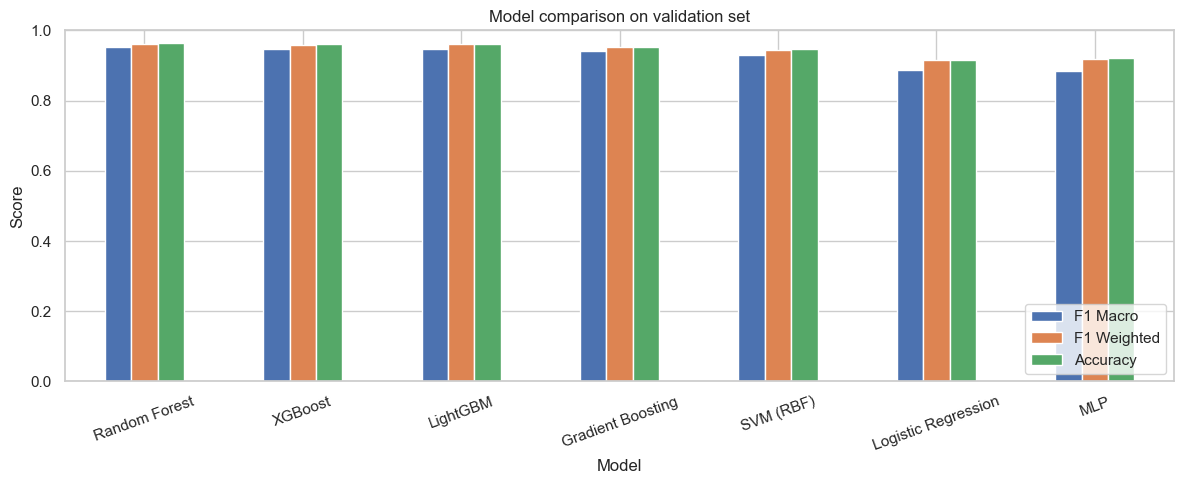

In [7]:
ax = results_df[['F1 Macro', 'F1 Weighted', 'Accuracy']].plot(
    kind='bar', figsize=(12, 5), ylim=(0, 1)
)
ax.set_title('Model comparison on validation set')
ax.set_ylabel('Score')
ax.tick_params(axis='x', rotation=20)
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

## 6. Cross-validation on best model

In [8]:
best_name = results_df.index[0]
best_model = models[best_name]
print(f'Best model: {best_name}')

X_trainval = np.vstack([X_train_s, X_val_s])
y_trainval = np.concatenate([y_train, y_val])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

if best_name in USE_SAMPLE_WEIGHT:
    sw_trainval = compute_sample_weight('balanced', y_trainval)
    cv_scores = cross_val_score(best_model, X_trainval, y_trainval,
                                cv=cv, scoring='f1_macro', n_jobs=-1,
                                fit_params={'sample_weight': sw_trainval})
else:
    cv_scores = cross_val_score(best_model, X_trainval, y_trainval,
                                cv=cv, scoring='f1_macro', n_jobs=-1)

print(f'5-fold CV F1 Macro: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold scores: {cv_scores.round(4)}')

Best model: Random Forest
5-fold CV F1 Macro: 0.9692 ± 0.0036
Per-fold scores: [0.9682 0.9626 0.9729 0.9711 0.971 ]


## 7. Final evaluation on test set

In [9]:
if best_name in USE_SAMPLE_WEIGHT:
    sw_trainval = compute_sample_weight('balanced', y_trainval)
    best_model.fit(X_trainval, y_trainval, sample_weight=sw_trainval)
else:
    best_model.fit(X_trainval, y_trainval)

y_pred_test = best_model.predict(X_test_s)

print(f'=== {best_name} — Test set results ===')
print(classification_report(y_test, y_pred_test, target_names=le.classes_))

=== Random Forest — Test set results ===
              precision    recall  f1-score   support

  Aggressive       0.98      1.00      0.99        45
     Chaotic       1.00      0.92      0.96        36
      Clumsy       0.97      1.00      0.98        60
Conservative       0.97      1.00      0.99        67
         Pro       1.00      0.89      0.94        18
        Slow       1.00      1.00      1.00        75

    accuracy                           0.98       301
   macro avg       0.99      0.97      0.98       301
weighted avg       0.98      0.98      0.98       301



## 8. Confusion matrix

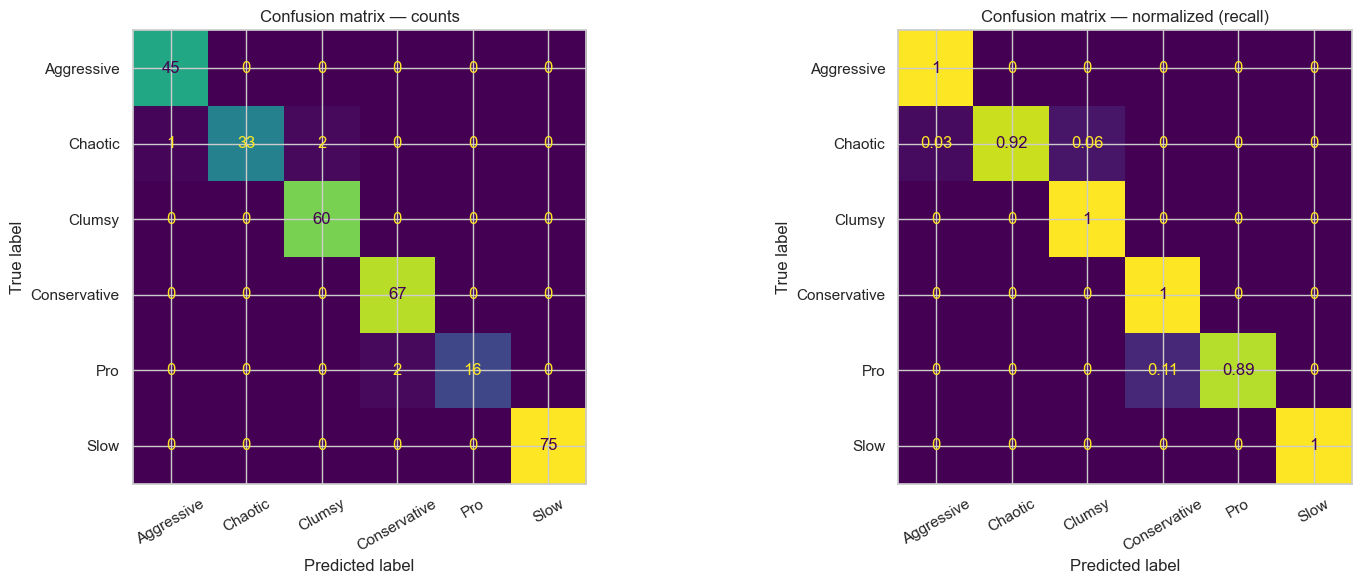

In [10]:
cm = confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
ConfusionMatrixDisplay(cm, display_labels=le.classes_).plot(ax=axes[0], colorbar=False)
axes[0].set_title('Confusion matrix — counts')
axes[0].tick_params(axis='x', rotation=30)

# Normalized (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
ConfusionMatrixDisplay(cm_norm.round(2), display_labels=le.classes_).plot(ax=axes[1], colorbar=False)
axes[1].set_title('Confusion matrix — normalized (recall)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 9. Per-class F1 comparison across all models

/Users/ronald/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


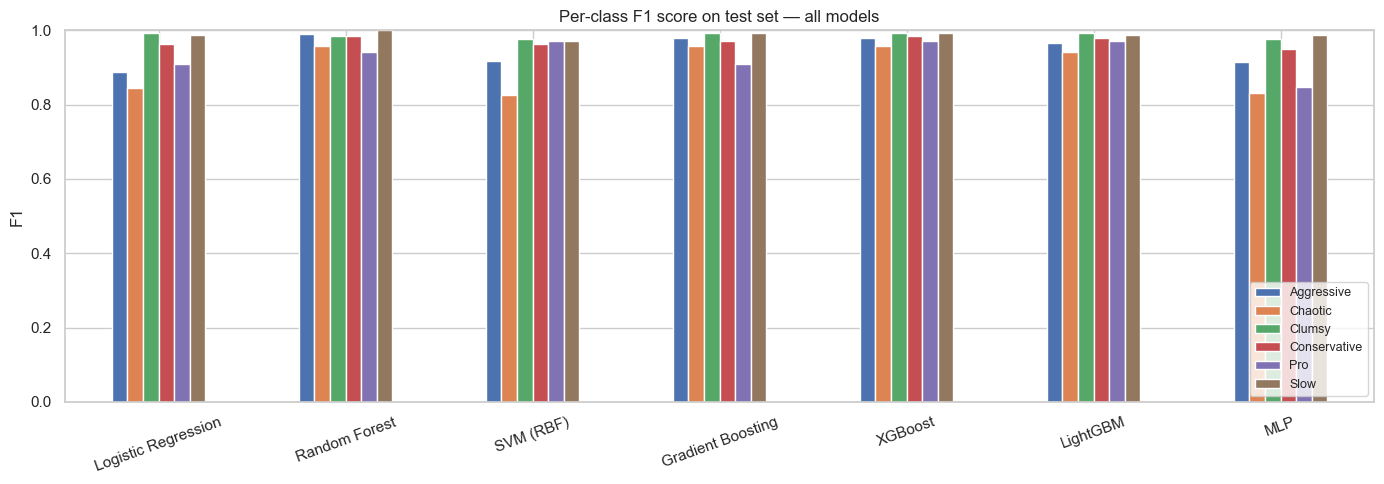

,Aggressive,Chaotic,Clumsy,Conservative,Pro,Slow
Logistic Regression,0.889,0.845,0.992,0.964,0.909,0.986
Random Forest,0.989,0.957,0.984,0.985,0.941,1.000
SVM (RBF),0.917,0.825,0.976,0.964,0.971,0.973
Gradient Boosting,0.978,0.957,0.992,0.971,0.909,0.993
XGBoost,0.978,0.957,0.992,0.985,0.971,0.993
LightGBM,0.967,0.943,0.992,0.978,0.971,0.986
MLP,0.915,0.831,0.976,0.950,0.848,0.986


In [11]:
per_class_f1 = {}
for name, model in models.items():
    y_pred = model.predict(X_test_s)
    f1s = f1_score(y_test, y_pred, average=None, labels=range(len(le.classes_)))
    per_class_f1[name] = f1s

per_class_df = pd.DataFrame(per_class_f1, index=le.classes_).T

per_class_df.plot(kind='bar', figsize=(14, 5), ylim=(0, 1))
plt.title('Per-class F1 score on test set — all models')
plt.ylabel('F1')
plt.xticks(rotation=20)
plt.legend(loc='lower right', fontsize=9)
plt.tight_layout()
plt.show()

per_class_df.round(3)

## 10. Save best model

In [12]:
model_path = MODELS_DIR / 'best_model.joblib'
joblib.dump(best_model, model_path)

# Save metadata
meta = {
    'model_name': best_name,
    'feature_cols': FEATURE_COLS,
    'classes': list(le.classes_),
    'test_f1_macro': round(f1_score(y_test, y_pred_test, average='macro'), 4),
    'test_accuracy': round((y_pred_test == y_test).mean(), 4),
}
pd.Series(meta).to_json(MODELS_DIR / 'model_meta.json')

print(f'Model saved: {model_path}')
print(f'Model: {best_name}')
print(f'Test F1 Macro: {meta["test_f1_macro"]}')
print(f'Test Accuracy: {meta["test_accuracy"]}')

Model saved: models/best_model.joblib
Model: Random Forest
Test F1 Macro: 0.9759
Test Accuracy: 0.9834


## 12. Inference example
How to classify a new player from a single race.

In [13]:
import json

if not hasattr(best_model, 'estimators_'):
    raise RuntimeError(
        f"The best model ({best_name}) is not a Random Forest and cannot be exported to JSON. "
        "Re-run with Random Forest selected, or use the standalone export script for other model types."
    )

RAW_FEATURE_COLS = [
    'lapTime_delta', 'position_delta', 'mapCollisions_total',
    'shellsUsed_total', 'bananasUsed_total', 'mushroomsUsed_total',
    'starsUsed_total', 'bananaHitsReceived_total', 'shellHitsReceived_total',
]

JSON_PATH = Path('../../Data/classifier_rules/player_classifier.json')
JSON_PATH.parent.mkdir(parents=True, exist_ok=True)

export_payload = {
    'classLabels':      list(le.classes_),
    'rawFeatureColumns': RAW_FEATURE_COLS,
    'allFeatureColumns': FEATURE_COLS,
    'engineeredFeatures': {
        'aggressiveness':     'shellsUsed_total + bananasUsed_total',
        'hit_ratio':          '(bananaHitsReceived_total + shellHitsReceived_total) / (aggressiveness + 1)',
        'powerup_efficiency': 'aggressiveness / (mapCollisions_total + 1)',
    },
    'scalerMean':  [float(v) for v in scaler.mean_],
    'scalerScale': [float(v) for v in scaler.scale_],
    'trees': [],
}

for estimator in best_model.estimators_:
    tree = estimator.tree_
    predicted_class_indices = np.argmax(tree.value[:, 0, :], axis=1).astype(int).tolist()
    export_payload['trees'].append({
        'featureIndices':        tree.feature.astype(int).tolist(),
        'thresholds':            [float(v) for v in tree.threshold.tolist()],
        'leftChildren':          tree.children_left.astype(int).tolist(),
        'rightChildren':         tree.children_right.astype(int).tolist(),
        'predictedClassIndices': predicted_class_indices,
    })

with JSON_PATH.open('w', encoding='utf-8') as f:
    json.dump(export_payload, f, ensure_ascii=False, indent=2)

print(f'Exported to: {JSON_PATH.resolve()}')
print(f'  Classes ({len(le.classes_)}): {list(le.classes_)}')
print(f'  Trees: {len(export_payload["trees"])}')
print(f'  Features: {len(FEATURE_COLS)} ({len(RAW_FEATURE_COLS)} raw + 3 engineered)')

Exported to: /Users/ronald/master_iadb/tfm/Proyecto_Final_IA/Assets/Data/classifier_rules/player_classifier.json
  Classes (6): ['Aggressive', 'Chaotic', 'Clumsy', 'Conservative', 'Pro', 'Slow']
  Trees: 300
  Features: 12 (9 raw + 3 engineered)


## 11. Inference example
How to classify a new player from a single race.

In [14]:
def predict_player(race: dict) -> str:
    """
    Classifies a player given their aggregated race stats.
    race: dict with the 9 raw columns (averages/totals over 3 laps).
    Returns the predicted player_type string.
    """
    raw = pd.DataFrame([race])

    # Replicate the same feature engineering as the EDA notebook
    raw['aggressiveness']     = raw['shellsUsed_total'] + raw['bananasUsed_total']
    raw['hit_ratio']          = (raw['bananaHitsReceived_total'] + raw['shellHitsReceived_total']) / (raw['aggressiveness'] + 1)
    raw['powerup_efficiency'] = raw['aggressiveness'] / (raw['mapCollisions_total'] + 1)

    X_new = scaler.transform(raw[FEATURE_COLS].values)
    pred  = best_model.predict(X_new)
    return le.inverse_transform(pred)[0]


# --- Example races ---

pro_example = {
    'lapTime_delta': 8.5, 'position_delta': 1.2,
    'mapCollisions_total': 2, 'shellsUsed_total': 3,
    'bananasUsed_total': 1, 'mushroomsUsed_total': 4,
    'starsUsed_total': 0, 'bananaHitsReceived_total': 1,
    'shellHitsReceived_total': 1,
}

clumsy_example = {
    'lapTime_delta': 25.0, 'position_delta': 5.3,
    'mapCollisions_total': 30, 'shellsUsed_total': 1,
    'bananasUsed_total': 1, 'mushroomsUsed_total': 0,
    'starsUsed_total': 0, 'bananaHitsReceived_total': 5,
    'shellHitsReceived_total': 4,
}

slow_example = {
    'lapTime_delta': 35.0, 'position_delta': 5.8,
    'mapCollisions_total': 4, 'shellsUsed_total': 0,
    'bananasUsed_total': 1, 'mushroomsUsed_total': 1,
    'starsUsed_total': 0, 'bananaHitsReceived_total': 1,
    'shellHitsReceived_total': 0,
}

print('Pro example    →', predict_player(pro_example))
print('Clumsy example →', predict_player(clumsy_example))
print('Slow example   →', predict_player(slow_example))

Pro example    → Pro
Clumsy example → Clumsy
Slow example   → Slow
